Shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimete

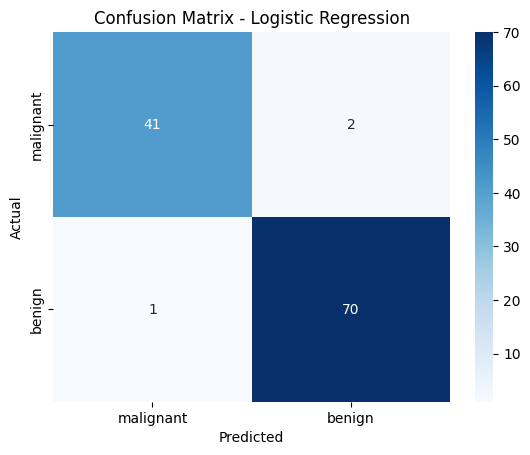

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]
Accuracy Score: 0.9473684210526315
Precision Score: 0.9473684210526315
Recall Score: 0.9473684210526315
F1 Score: 0.9473684210526315
Confusion Matrix:
 [[40  3]
 [ 3 68]]


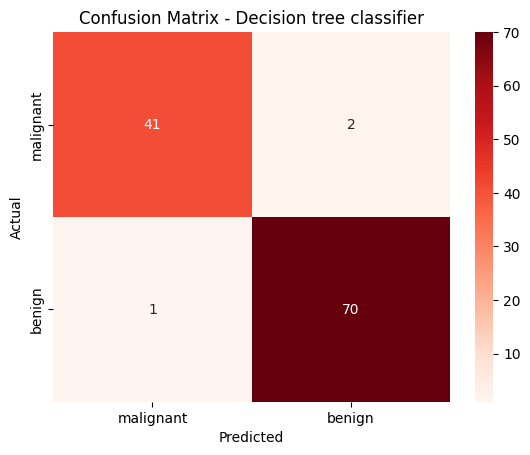

In [13]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
data=load_breast_cancer(as_frame=True)
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape:", x.shape)

print(x.head())


print(y.head())


print(x.columns.tolist())


print(x.describe())


full_df = x.copy()
full_df["target"] = y
print(full_df.head())

print("\nMissing values per column:\n", x.isnull().sum().sum())


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)


x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)

pred=model.predict(x_test)
print(pred)

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Accuracy Score:",accuracy_score(y_test,pred))
print("Precision Score:",precision_score(y_test,pred,average='weighted'))
print("Recall Score:",recall_score(y_test,pred,average='weighted'))
print("F1 Score:",f1_score(y_test,pred,average='weighted'))

#conmfusion matrix
print("Confusion Matrix:\n",confusion_matrix(y_test,pred))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

from sklearn.tree import DecisionTreeClassifier
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

pred=model.predict(x_test)
print(pred)


print("Accuracy Score:",accuracy_score(y_test,pred))
print("Precision Score:",precision_score(y_test,pred,average='weighted'))
print("Recall Score:",recall_score(y_test,pred,average='weighted'))
print("F1 Score:",f1_score(y_test,pred,average='weighted'))

#conmfusion matrix
print("Confusion Matrix:\n",confusion_matrix(y_test,pred))



sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision tree classifier")
plt.show()

